In [4]:
#Name : Gulame Vishal Yashavant 
#Div: A 
#Roll No: 57

In [4]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [10]:
dataset_path = "C:/Users/pruth/Downloads/archive (1)/PlantVillage/train"

In [11]:
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 43444 images belonging to 38 classes.


In [12]:
train_dir = "C:/Users/pruth/Downloads/archive (1)/PlantVillage/train"
test_dir  = "C:/Users/pruth/Downloads/archive (1)/PlantVillage/val" 

In [13]:
img_height = 224
img_width = 224
batch_size = 32

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 43444 images belonging to 38 classes.
,Found 10861 images belonging to 38 classes.


In [16]:
num_classes = train_data.num_classes

In [17]:
model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

D:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
,  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_data,
    epochs=2,
    validation_data=test_data
)

Epoch 1/2
,1358/1358 ━━━━━━━━━━━━━━━━━━━━ 164049s 121s/step - accuracy: 0.4623 - loss: 1.9671 - val_accuracy: 0.6918 - val_loss: 1.0507
,Epoch 2/2
,1358/1358 ━━━━━━━━━━━━━━━━━━━━ 4252s 3s/step - accuracy: 0.6437 - loss: 1.1972 - val_accuracy: 0.7811 - val_loss: 0.6985


In [20]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 136s 399ms/step - accuracy: 0.7811 - loss: 0.6985
,Test Loss: 0.6985215544700623
,Test Accuracy: 0.7811435461044312


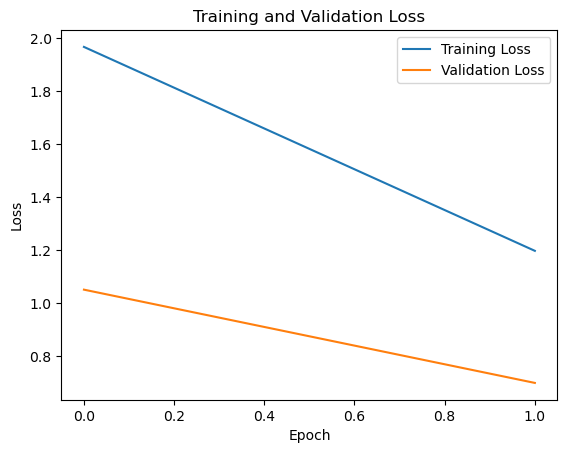

In [21]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

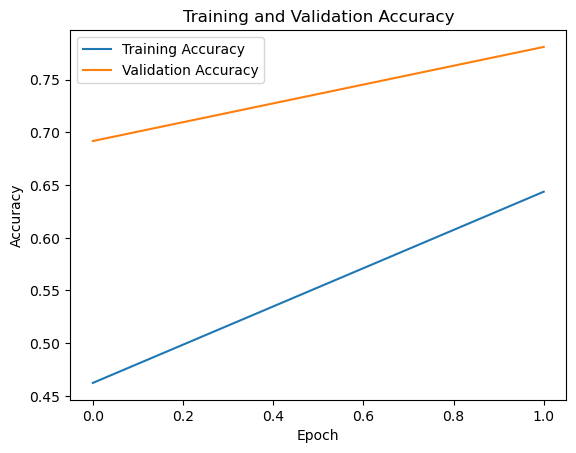

In [22]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()